In [5]:
import torch
import shap
import sklearn
print("torch:", torch.__version__)
print("shap :", shap.__version__)
print("scikit-learn :", sklearn.__version__)

torch: 1.13.1
shap : 0.41.0
scikit-learn : 1.3.2


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import copy
import random
import os

D:\anaconda\envs\shap_env\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
print(os.getcwd())
os.chdir('D:\\哮喘乳酸化单细胞开篇\\11.深度学习')
print(os.getcwd())

C:\Users\86186\Documents
D:\哮喘乳酸化单细胞开篇\11.深度学习


In [3]:
# ----------------------
# 环境设置与数据加载
# ----------------------
def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 2025
set_random_seed(seed)

# 加载数据（确保第一列是样本ID）
dataset_train = pd.read_table("data.train.txt", index_col=0)
dataset_test = pd.read_table("data.test.txt", index_col=0)

# ----------------------
# 数据预处理
# ----------------------
def preprocess_data(df):
    df = df.copy()
    df['Type'] = df.index.map(lambda x: 0 if '_control' in x else 1)
    return df

df_train = preprocess_data(dataset_train)
df_test = preprocess_data(dataset_test)

# 分离特征和标签
X_train = df_train.iloc[:, :-1].values.astype(np.float32)
y_train = df_train.iloc[:, -1].values
X_test = df_test.iloc[:, :-1].values.astype(np.float32)
y_test = df_test.iloc[:, -1].values

# ----------------------
# 模型定义（严格按文献描述构建）
# ----------------------
class DNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            # 输入层（14节点 -> 根据文献描述，但实际使用数据特征数）
            nn.Linear(input_size, 64),  # 第一隐藏层
            nn.Linear(64, 64),          # 第二隐藏层
            nn.Linear(64, 2)            # 输出层
            # 注意：文献中提到的softmax已由CrossEntropyLoss自动处理
        )
        
        # 文献未说明初始化方法，保持默认初始化
        # （原始代码的Kaiming初始化可能更优，但为符合文献描述此处移除）

    def forward(self, x):
        return self.net(x)

# ----------------------
# 训练参数配置（严格遵循文献）
# ----------------------
# 文献参数
BATCH_SIZE = 64        # 文献指定初始值
INIT_LR = 0.0001       # 文献设定初始学习率
EPOCHS = 1000          # 文献要求≥1000轮
PATIENCE = 200          # 连续20个epoch验证集准确率无提升则停止
best_acc = 0.0         # 新增
early_stop_counter = 0 # 新增
best_model = None  # 新增
# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 转换为Tensor
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------
# 模型初始化
# ----------------------
model = DNN(input_size=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=INIT_LR)  # 使用默认β参数

# ----------------------
# 动态学习率调整（文献提到持续调整）
# ----------------------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    factor=0.5, 
    patience=20,
    verbose=True
)

# ----------------------
# 训练循环（按文献描述实现动态调整）
# ----------------------
best_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# 文献建议的验证集划分（原代码未明确，按常规添加）
#X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
#    X_train_scaled, y_train, test_size=0.8, stratify=y_train, random_state=seed
#)

#val_dataset = TensorDataset(
#    torch.tensor(X_val_split, dtype=torch.float32),
#    torch.tensor(y_val_split, dtype=torch.long)
#)
#val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

for epoch in range(EPOCHS):
    # 训练阶段
    model.train()
    epoch_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    # 验证阶段
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    # 计算指标
    train_loss = epoch_loss / len(train_loader)
    train_acc = 100 * correct / total
    val_loss = val_loss / len(test_loader)
    val_acc = 100 * val_correct / val_total
    
    # 动态调整学习率（文献所述策略）
    scheduler.step(val_acc)
    
    # 记录指标
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # 保存最佳模型
    if val_acc > best_acc:
        best_acc = val_acc
        best_model = copy.deepcopy(model.state_dict())
        early_stop_counter = 0  # 重置计数器
    else:
        early_stop_counter += 1
    
    # 打印早停进度
    if (epoch+1) % 10 == 0:
        print(f'Early stopping counter: {early_stop_counter}/{PATIENCE}')
    
    # 触发早停条件
    if early_stop_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch+1}!')
        print(f'Best val Acc: {best_acc:.2f}%')
        break  # 跳出训练循环
    
    # 文献建议的动态参数调整逻辑
    if (epoch+1) % 100 == 0:  # 每100轮评估调整
        # 根据验证曲线调整批次大小（示例逻辑）
        current_lr = optimizer.param_groups[0]['lr']
        if val_acc < 70 and current_lr > 1e-5:
            new_lr = current_lr * 0.5
            print(f"Adjusting LR from {current_lr:.2e} to {new_lr:.2e}")
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr
        
        # 根据过拟合程度调整批次大小（示例逻辑）
        if (train_acc - val_acc) > 15:  # 过拟合明显
            global BATCH_SIZE
            BATCH_SIZE = max(8, BATCH_SIZE//2)
            print(f"Reducing batch size to {BATCH_SIZE}")
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # 打印进度
    if (epoch+1) % 50 == 0:
        print(f'Epoch {epoch+1:04d}/{EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

Early stopping counter: 0/200
Early stopping counter: 10/200
Early stopping counter: 20/200
Epoch 00031: reducing learning rate of group 0 to 5.0000e-05.
Early stopping counter: 30/200
Early stopping counter: 40/200
Epoch 0050/1000 | Train Loss: 0.4533 Acc: 85.81% | Val Loss: 0.4355 Acc: 82.41%
Epoch 00052: reducing learning rate of group 0 to 2.5000e-05.
Early stopping counter: 50/200
Early stopping counter: 60/200
Epoch 00073: reducing learning rate of group 0 to 1.2500e-05.
Early stopping counter: 70/200
Early stopping counter: 80/200
Epoch 00094: reducing learning rate of group 0 to 6.2500e-06.
Early stopping counter: 90/200
Epoch 0100/1000 | Train Loss: 0.4212 Acc: 85.81% | Val Loss: 0.4117 Acc: 82.41%
Early stopping counter: 100/200
Epoch 00115: reducing learning rate of group 0 to 3.1250e-06.
Early stopping counter: 110/200
Early stopping counter: 120/200
Epoch 00136: reducing learning rate of group 0 to 1.5625e-06.
Early stopping counter: 130/200
Early stopping counter: 140/200

In [4]:
# 最终评估与可视化
# ----------------------
best_epoch = np.argmax(val_accs)  # 直接取验证集最高点
print(f'最佳epoch: {best_epoch+1}, 验证准确率: {val_accs[best_epoch]:.2f}%')
model.load_state_dict(best_model)
model.eval()

# 测试集评估
test_correct = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        test_correct += model(inputs).argmax(1).eq(labels).sum().item()
test_acc = 100 * test_correct / len(test_loader.dataset)

print(f"\n{'='*40}")
print(f"Final Test Accuracy: {test_acc:.2f}%")
print(f"{'='*40}")

最佳epoch: 10, 验证准确率: 84.26%

Final Test Accuracy: 84.26%


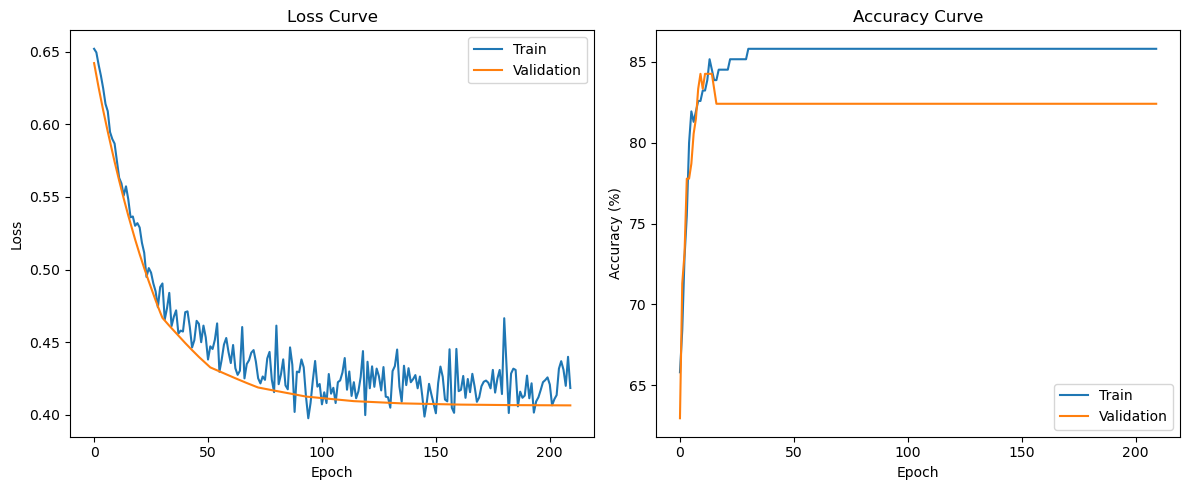

In [5]:
# 可视化曲线（文献强调的监控指标）
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves.pdf', dpi=300)
plt.show()

In [6]:
background_data = torch.tensor(X_test, dtype=torch.float32)
print(background_data.shape)

torch.Size([108, 8])


In [7]:
import shap
import numpy as np

In [8]:
background_data = shap.DeepExplainer(model,torch.tensor(X_test, dtype=torch.float32))

In [9]:
# 计算SHAP值
shap_values = background_data.shap_values(torch.tensor(X_test, dtype=torch.float32))
shap_values

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.


[array([[ 4.23002336e-03,  3.04293673e-04, -3.39973602e-04,
          3.09655983e-02, -4.38876497e-03, -2.66234130e-02,
         -1.92907441e-03,  4.23503853e-02],
        [-2.64626611e-02,  1.40021584e-04,  1.54510874e-03,
          2.01422527e-01,  8.41273461e-03, -3.43806818e-02,
          2.40731891e-03, -4.76605557e-02],
        [ 3.95320496e-03,  1.11054658e-04, -3.35904630e-03,
          1.69831570e-02,  3.08876799e-04, -3.76008800e-03,
          1.94379012e-03,  8.25582147e-02],
        [ 3.30366823e-03, -1.10253837e-04, -1.02474978e-02,
          8.23289230e-02, -5.42005571e-03, -5.86475106e-03,
         -8.08319077e-04, -2.06377115e-02],
        [ 3.86528322e-03,  1.65116217e-04,  7.86963198e-03,
         -2.02242211e-02, -5.18228812e-03,  2.61520986e-02,
         -5.28158445e-04, -2.95381863e-02],
        [-4.28276975e-03,  1.34391245e-04,  1.66177354e-03,
          5.69593236e-02,  1.55933527e-03, -1.47055816e-02,
         -4.17011930e-03, -1.85092427e-02],
        [-6.7952

In [10]:
# 可视化第一个样本的SHAP值
shap.initjs()  # 初始化JavaScript环境

In [11]:
# 计算SHAP值
shap_values = background_data.shap_values(torch.tensor(X_test, dtype=torch.float32))
shap_values

[array([[ 4.23002336e-03,  3.04293673e-04, -3.39973602e-04,
          3.09655983e-02, -4.38876497e-03, -2.66234130e-02,
         -1.92907441e-03,  4.23503853e-02],
        [-2.64626611e-02,  1.40021584e-04,  1.54510874e-03,
          2.01422527e-01,  8.41273461e-03, -3.43806818e-02,
          2.40731891e-03, -4.76605557e-02],
        [ 3.95320496e-03,  1.11054658e-04, -3.35904630e-03,
          1.69831570e-02,  3.08876799e-04, -3.76008800e-03,
          1.94379012e-03,  8.25582147e-02],
        [ 3.30366823e-03, -1.10253837e-04, -1.02474978e-02,
          8.23289230e-02, -5.42005571e-03, -5.86475106e-03,
         -8.08319077e-04, -2.06377115e-02],
        [ 3.86528322e-03,  1.65116217e-04,  7.86963198e-03,
         -2.02242211e-02, -5.18228812e-03,  2.61520986e-02,
         -5.28158445e-04, -2.95381863e-02],
        [-4.28276975e-03,  1.34391245e-04,  1.66177354e-03,
          5.69593236e-02,  1.55933527e-03, -1.47055816e-02,
         -4.17011930e-03, -1.85092427e-02],
        [-6.7952

In [12]:
y_test = torch.tensor(y_test, dtype=torch.float32)

In [13]:
feature_names = df_train.columns[:-1].tolist()
feature_names

['FKBP3', 'RBM14', 'MAGOH', 'TMSB4X', 'CACYBP', 'RCC2', 'SMARCC1', 'WAS']

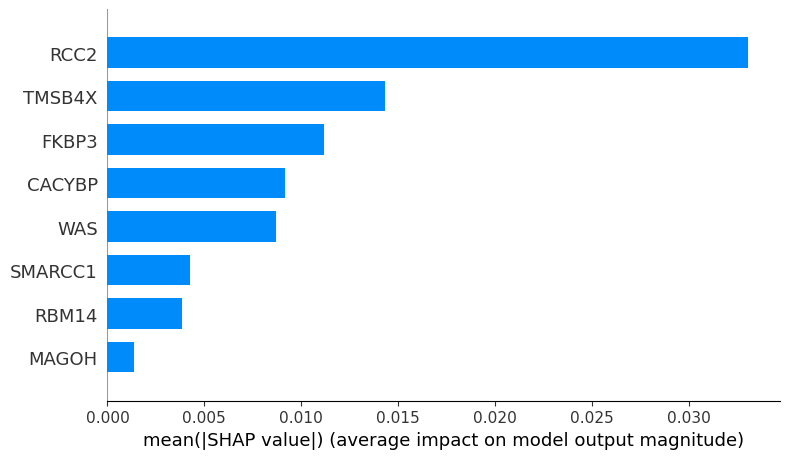

In [14]:
shap.summary_plot(shap_values[1], torch.tensor(X_test, dtype=torch.float32), show=False, feature_names=feature_names, plot_type="bar")
# 保存图表
plt.savefig('shap_summary_plot_bar_dnn.PDF', dpi=600, bbox_inches='tight')
# 显示图表
plt.show()

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


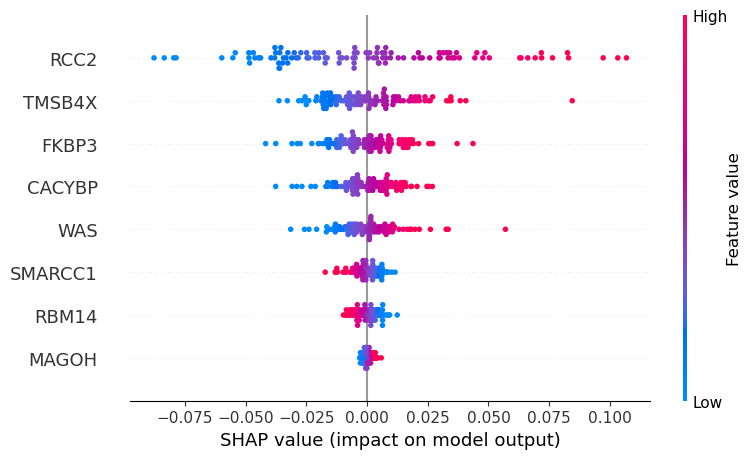

In [15]:
shap.summary_plot(shap_values[1], torch.tensor(X_test, dtype=torch.float32), show=False, feature_names=feature_names, plot_type="dot")
# 保存图表
plt.savefig('shap_summary_plot_dot_dnn.PDF', dpi=600, bbox_inches='tight')
# 显示图表
plt.show()